<a href="https://colab.research.google.com/github/Zeldian-Soul/AI-ML-lab-/blob/main/Banknote_Authentication_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Banknote Authentication using Machine Learning

## Classification Algorithms
1. Decision Tree Classifier
2. Random Forest Classifier
3. Support Vector Classifier (SVC)

Additional visualizations:
- ID3-style Decision Tree using entropy
- One tree from the Random Forest
- Stacking Classifier
- ROC and Precision-Recall curves
- Accuracy, Precision, Recall and F1-Score comparison


## 1. Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)


## 2. Load and Preprocess the Dataset

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

df = pd.read_csv(url, header=None)

df.columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("\nDataset shape:", df.shape)
df.head()


Missing values:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Dataset shape: (1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
# Separate features and target
X = df.drop("class", axis=1)
y = df["class"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature scaling for SVC and Stacking
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 1097
Testing samples: 275


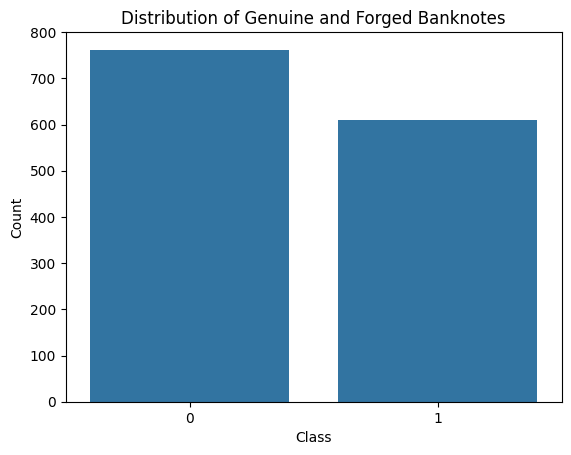

In [ ]:
# Class distribution
sns.countplot(x=y)
plt.title("Distribution of Genuine and Forged Banknotes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


## 3. Decision Tree Classification

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



### Decision Tree Visualization

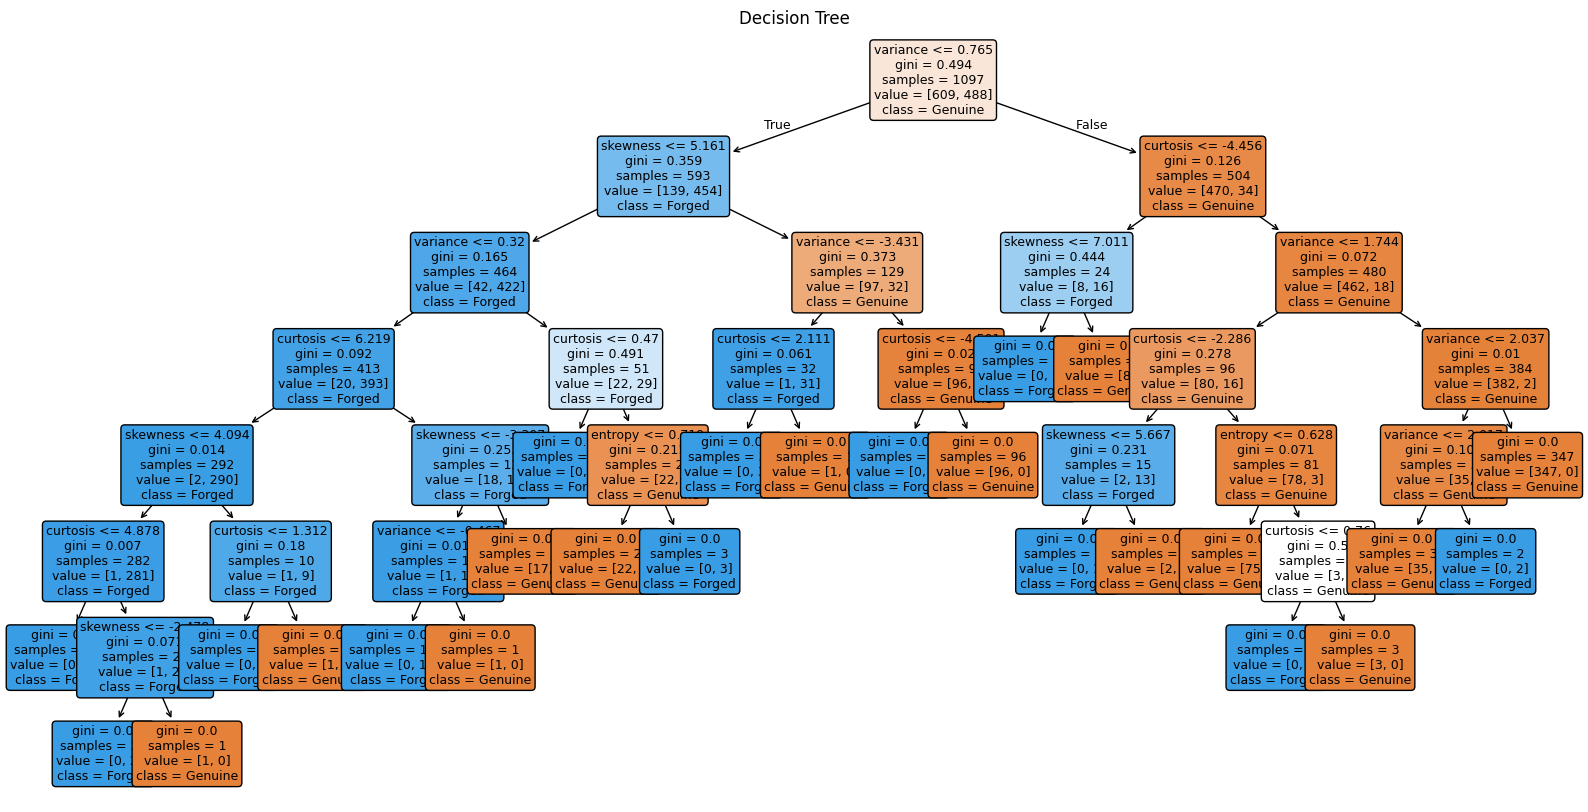

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Genuine", "Forged"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree")
plt.show()


## 4. Random Forest Classification

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00       153
           1       0.99      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



### Random Forest Tree Visualization

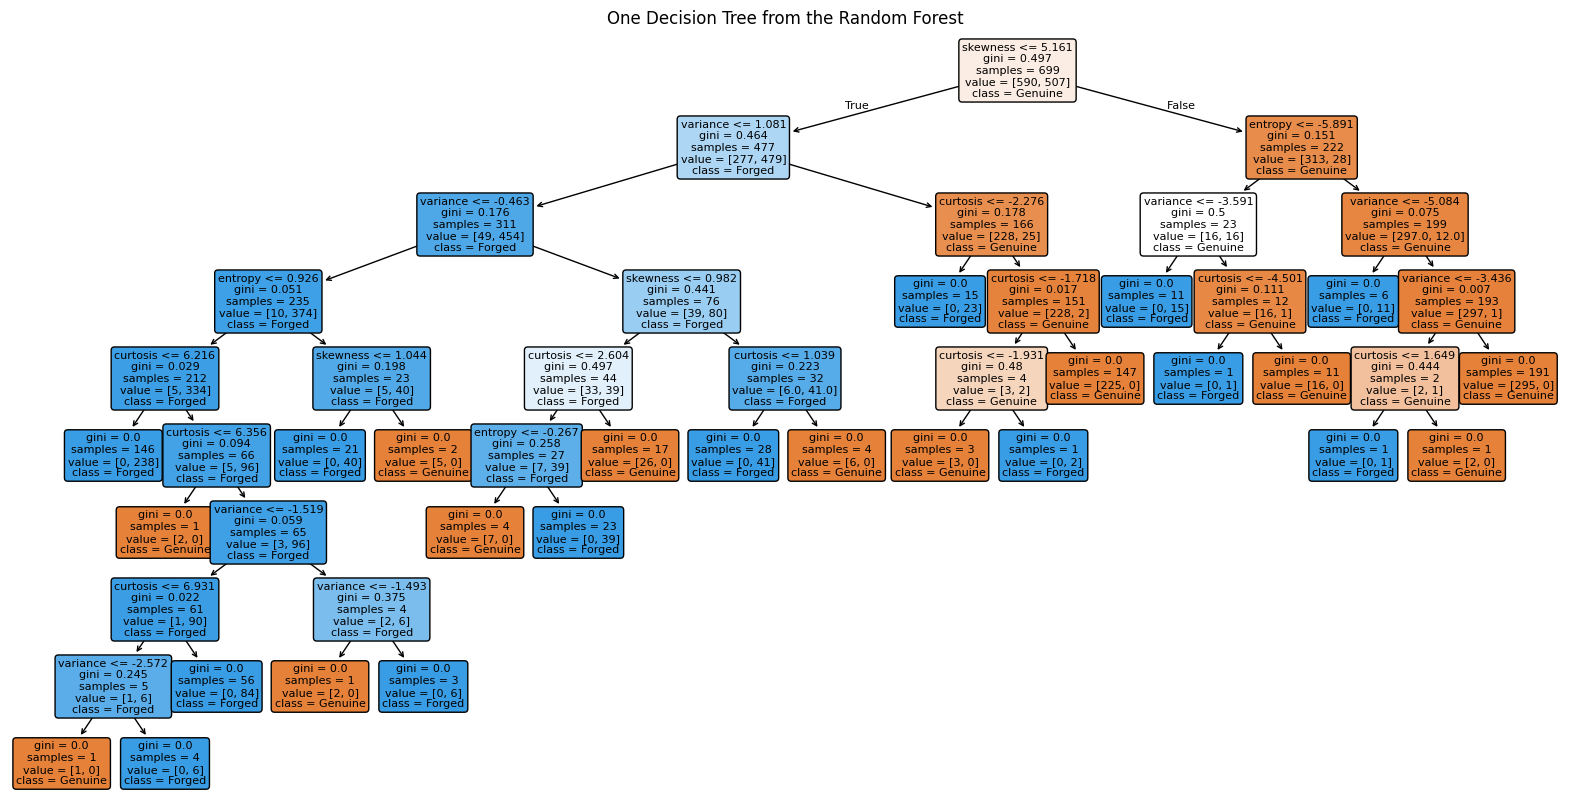

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    class_names=["Genuine", "Forged"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("One Decision Tree from the Random Forest")
plt.show()


## 5. Support Vector Classification (SVC)

In [ ]:
svc_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)
svc_model.fit(X_train_scaled, y_train)

y_pred_svc = svc_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svc))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



## 6. ID3-style Decision Tree using Entropy

In [ ]:
id3_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
id3_model.fit(X_train, y_train)

y_pred_id3 = id3_model.predict(X_test)

print(classification_report(y_test, y_pred_id3))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



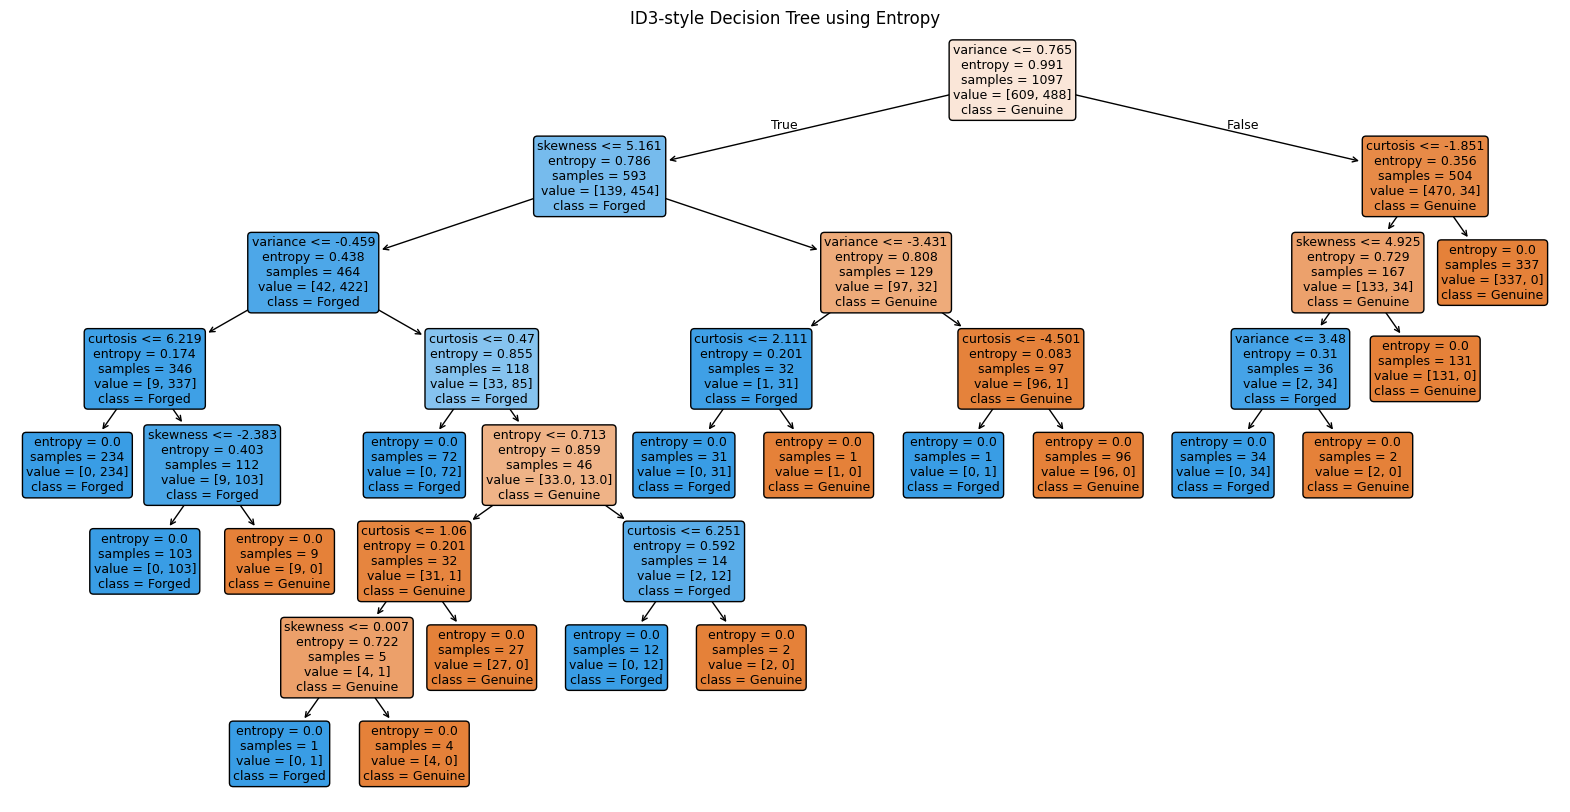

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    id3_model,
    feature_names=X.columns,
    class_names=["Genuine", "Forged"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("ID3-style Decision Tree using Entropy")
plt.show()


## 7. Stacking Classifier

In [ ]:
base_models = [
    ("decision_tree", DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )),
    ("random_forest", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )),
    ("svc", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_model.fit(X_train_scaled, y_train)
y_pred_stack = stacking_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_stack))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



### Stacking Confusion Matrix

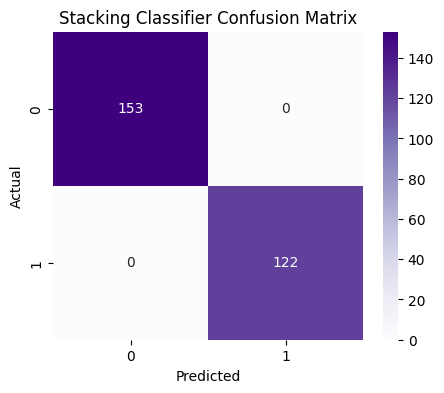

In [ ]:
cm_stack = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_stack,
    annot=True,
    fmt="d",
    cmap="Purples"
)
plt.title("Stacking Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 8. Classification Metrics

In [ ]:
predictions = {
    "Decision Tree": y_pred_dt,
    "ID3-style Tree": y_pred_id3,
    "Random Forest": y_pred_rf,
    "SVC": y_pred_svc,
    "Stacking": y_pred_stack
}

results = pd.DataFrame({
    "Model": list(predictions.keys()),
    "Accuracy": [
        accuracy_score(y_test, p) for p in predictions.values()
    ],
    "Precision": [
        precision_score(y_test, p) for p in predictions.values()
    ],
    "Recall": [
        recall_score(y_test, p) for p in predictions.values()
    ],
    "F1-Score": [
        f1_score(y_test, p) for p in predictions.values()
    ]
})

results.round(4)


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.9927,0.9839,1.0,0.9919
1,ID3-style Tree,0.9927,0.9839,1.0,0.9919
2,Random Forest,0.9964,0.9919,1.0,0.9959
3,SVC,1.0000,1.0000,1.0,1.0000
4,Stacking,1.0000,1.0000,1.0,1.0000


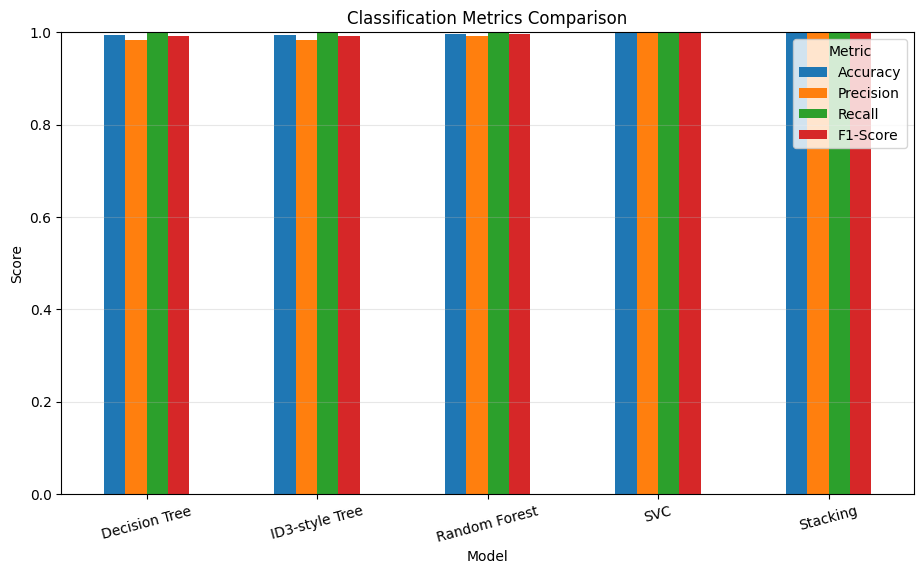

In [ ]:
# Visual comparison of the four required classification metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1)
plt.title("Classification Metrics Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 9. ROC Curves

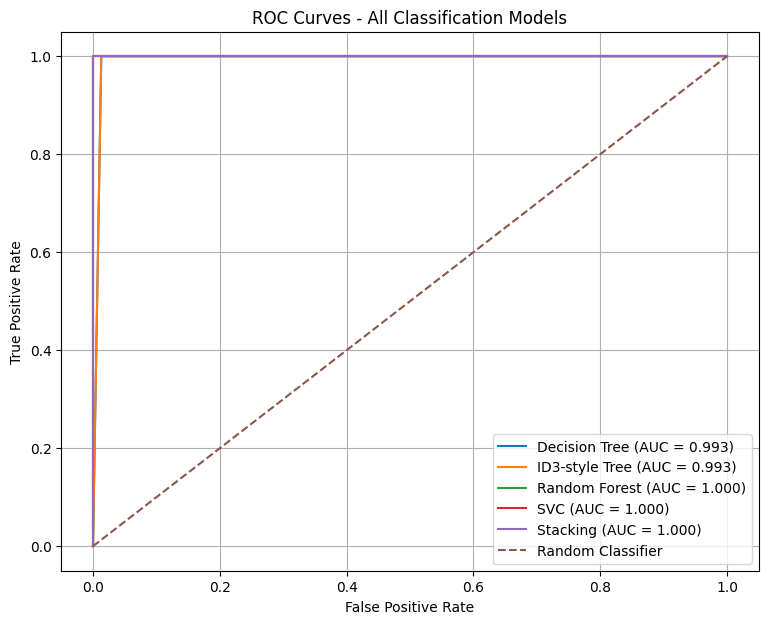

In [ ]:
model_scores = {
    "Decision Tree": dt_model.predict_proba(X_test)[:, 1],
    "ID3-style Tree": id3_model.predict_proba(X_test)[:, 1],
    "Random Forest": rf_model.predict_proba(X_test)[:, 1],
    "SVC": svc_model.predict_proba(X_test_scaled)[:, 1],
    "Stacking": stacking_model.predict_proba(X_test_scaled)[:, 1]
}

plt.figure(figsize=(9, 7))

for name, scores in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Classification Models")
plt.legend()
plt.grid(True)
plt.show()


## 10. Precision-Recall Curves

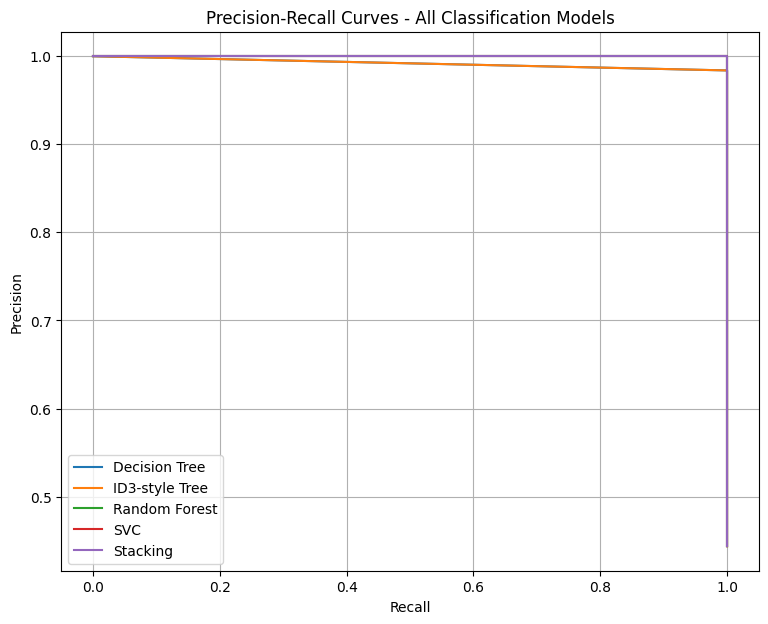

In [ ]:
plt.figure(figsize=(9, 7))

for name, scores in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - All Classification Models")
plt.legend()
plt.grid(True)
plt.show()


## 11. Confusion Matrices for the Three Main Classifiers

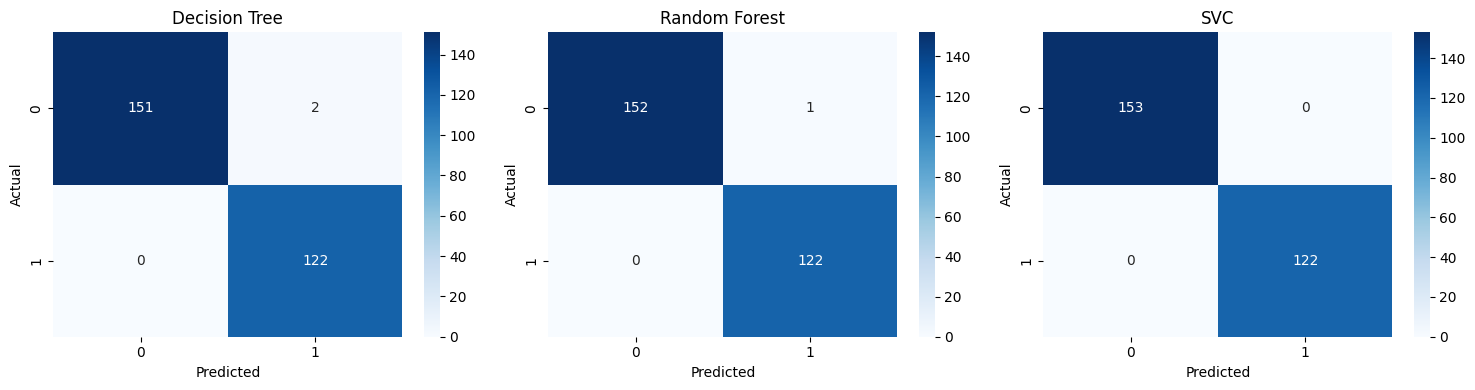

In [ ]:
main_models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVC": y_pred_svc
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, main_models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 12. Final Results

In [ ]:
results.round(4)


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.9927,0.9839,1.0,0.9919
1,ID3-style Tree,0.9927,0.9839,1.0,0.9919
2,Random Forest,0.9964,0.9919,1.0,0.9959
3,SVC,1.0000,1.0000,1.0,1.0000
4,Stacking,1.0000,1.0000,1.0,1.0000
